# ML LAB-3
# Name: Sneha Kanjwani
# CMS ID: 023-24-0273
# Section: H
# GitHub Profile: https://github.com/snehakanjwani30
# Kaggle Profile: https://www.kaggle.com/snehakanjwani
# Dataset: Telco Customer Churn (cleaned in Lab 2)
# Dataset Source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Part 1 & 2 — Problem Definition & Dataset Verification

In [1]:
#TASK-1
import pandas as pd
df = pd.read_csv("clean_churn.csv")
df.shape
df.info()
df.isnull().sum()
df['Churn'].value_counts()
#This code loads the clean_churn.csv dataset using Pandas. Then it checks the size of the dataset, 
#shows information about columns and data types, checks for missing values, and counts how many customers are in each Churn category.

<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    
 17  Monthl

Churn
No     5164
Yes    1857
Name: count, dtype: int64

In [ ]:
#TASK-2
#The goal of this machine learning task is to predict whether a telecom customer will leave the company or stay. This is useful 
#for the business becuase it can help identify the customers who may leave so the company can take steps to retain them.

# Part 3 — Feature & Target Preparation

In [2]:
#TASK-3
y = df['Churn'].map({'No': 0, 'Yes':1})
y.head()
y.isnull().sum()
X = df.drop(columns=['Churn'])
X.head()
#The target variable y is the Churn column, where Yes is encoded as 1 and No as 0. 
#The feature variable X contains the remaining 19 columns that will be used by 
#the Decision Tree to predict customer churn.

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [3]:
#TASK-4
X = pd.get_dummies(X,drop_first=True,dtype=int)
print(X.head())
print('Data types: ')
print(X.dtypes)
# One-hot encoding was used to convert the categorical features into numeric values. 
# This method represents each category using 0 and 1, which makes the data suitable 
# for training a Decision Tree model. drop_first=True was used to remove one 
# unnecessary category from each group.

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85            0   
1              0      34           56.95       1889.50            1   
2              0       2           53.85        108.15            1   
3              0      45           42.30       1840.75            1   
4              0       2           70.70        151.65            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                               1                  0  ...   
1                               0                  0  ...   
2                               0                  0  ...   
3               

In [4]:
#TASK-5
print('All columns numeric:', all(pd.api.types.is_numeric_dtype(dtype) for dtype in X.dtypes))
print('Total missing values:',X.isnull().sum().sum())
#This code checks whether all columns in X are numeric and counts the total number of
# missing values in X. It helps us make sure the data is ready for machine learning.

All columns numeric: True
Total missing values: 0


# Part 4 — Train/Test Split

In [6]:
#TASK-6
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#TASK-7
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
#stratify=y is useful because the Churn target is imbalanced. It keeps a similar 
#proportion of churn and non-churn customers in both the training and testing sets, 
#making the evaluation more reliable.

X_train shape: (5616, 30)
X_test shape: (1405, 30)
y_train shape: (5616,)
y_test shape: (1405,)


# Part 5 — Baseline Decision Tree

In [7]:
#TASK-8
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
#This code creates a Decision Tree model and trains it using the training data. 
# Then it uses the trained model to predict the results for both training and testing data.

In [8]:
#TASK-9
print("Tree depth:", model.get_depth())
#The Decision Tree grew to a depth of 26. This is quite deep and is not surprising 
#because the default Decision Tree is allowed to keep splitting until stopping 
#conditions are reached. The high training accuracy and much lower test accuracy 
#suggest that the tree is overfitting.

Tree depth: 26


In [9]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)
#This code calculates the accuracy of the Decision Tree model on both training and testing data. 
# It then prints both accuracies to see how well the model performs.

Training accuracy: 0.9976851851851852
Test accuracy: 0.7224199288256228


# Part 6 — Model Evaluation

In [10]:
#TASK-10
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test,y_test_pred)
precision = precision_score(y_test,y_test_pred)
recall = recall_score(y_test,y_test_pred)
f1 = f1_score(y_test,y_test_pred)
print('Accuracy:',accuracy)
print('Precision:',precision)
print('Recall:',recall)
print('F1 score:',f1)
#The baseline Decision Tree achieved an accuracy of 72.24%. 
#However, its precision, recall, and F1-score were much lower, at 47.68%, 49.73%, 
#and 48.68%, respectively.

Accuracy: 0.7224199288256228
Precision: 0.47680412371134023
Recall: 0.49731182795698925
F1 score: 0.4868421052631579


[[830 203]
 [187 185]]


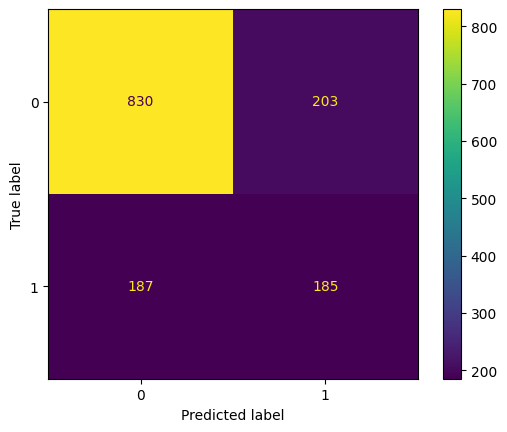

In [11]:
#TASK-11
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test,y_test_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
#The model correctly caught 185 actual churners and missed 187 actual churners.

# TASK-12
I would trust recall and F1-score more than accuracy because the dataset has class imbalance. Recall is important because we want to identify as many actual churners as possible, while F1-score considers both precision and recall. Accuracy can look reasonable even when the model performs poorly on the minority churn class.

# Part 7 — Overfitting Experiment

In [12]:
#TASK-13
print("Training accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)
print("Accuracy gap:", train_accuracy - test_accuracy)
#The training accuracy is 99.77%, while the test accuracy is 72.24%, giving a 
#large gap of about 27.53 percentage points. This suggests that the baseline 
#Decision Tree is overfitting because it performs extremely well on the training 
#data but much worse on unseen test data.

Training accuracy: 0.9976851851851852
Test accuracy: 0.7224199288256228
Accuracy gap: 0.27526525635956245


In [13]:
#TASK-14
depths = [2,3,4,5,6,8,10,None]
results = []
for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train,y_train)
    train_acc = accuracy_score(y_train,tree.predict(X_train))
    test_acc = accuracy_score(y_test,tree.predict(X_test))
    results.append({'max_depth': depth,
                   'train_accuracy': train_acc,
                   'test_accuracy': test_acc})
results_df = pd.DataFrame(results)
print(results_df)
#This code tests the Decision Tree model with different maximum depths. For each depth, it calculates 
# the training and testing accuracy and stores the results in a DataFrame to compare which depth gives better performance.

   max_depth  train_accuracy  test_accuracy
0        2.0        0.792201       0.783630
1        3.0        0.792201       0.783630
2        4.0        0.795228       0.784342
3        5.0        0.801816       0.787189
4        6.0        0.808226       0.785053
5        8.0        0.835470       0.778648
6       10.0        0.869124       0.770107
7        NaN        0.997685       0.722420


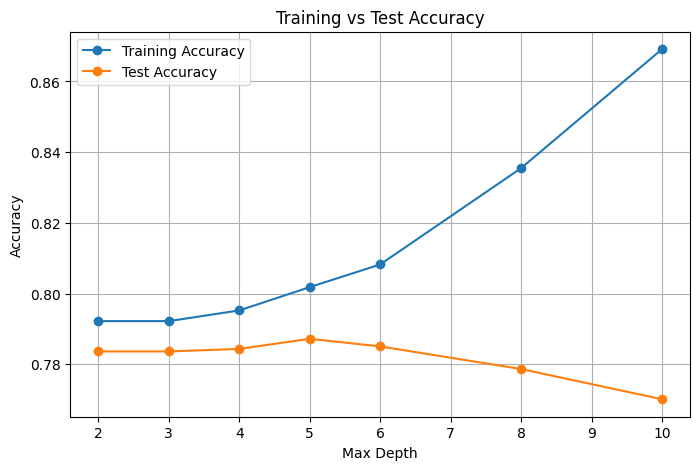

In [14]:
#TASK-15
plt.figure(figsize=(8,5))
plt.plot(results_df['max_depth'],
        results_df['train_accuracy'],
        marker='o',
        label='Training Accuracy')
plt.plot(results_df['max_depth'],
        results_df['test_accuracy'],
        marker='o',
        label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()
#The model starts to overfit at around depth 6. As the depth increases, 
#training accuracy continues to increase, but test accuracy starts to decrease. 
#This growing gap between training and test accuracy shows that the tree is 
#learning the training data too closely instead of generalizing well to unseen data.

# Part 8 — Model Comparison

# TASK-16
I selected a maximum depth of 5 because it gives the highest test accuracy of 78.72% among the tested depths. It also has a small gap between training accuracy (80.18%) and test accuracy, which suggests better generalization and less overfitting than the deeper trees.

In [15]:
#TASK-17
best_model = DecisionTreeClassifier(max_depth=5,random_state=42)
best_model.fit(X_train,y_train)
y_best_pred = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test,y_best_pred)
precision_best = precision_score(y_test,y_best_pred)
recall_best = recall_score(y_test,y_best_pred)
f1_best = f1_score(y_test,y_best_pred)
print('Accuracy:',accuracy_best)
print('Precision:',precision_best)
print('Recall:',recall_best)
print('F1 score:',f1_best)
#The Decision Tree with a maximum depth of 5 achieved an accuracy of 78.72%. 
#Its precision was 65.15%, recall was 42.20%, and F1-score was 51.22%. 
#The model performs better than the unrestricted tree because limiting the 
#depth reduces overfitting and improves its ability to generalize to unseen data.

Accuracy: 0.7871886120996441
Precision: 0.6514522821576764
Recall: 0.4220430107526882
F1 score: 0.5122349102773246


In [16]:
#TASK-18
entropy_model = DecisionTreeClassifier(max_depth=5,criterion='entropy',random_state=42)
entropy_model.fit(X_train,y_train)
y_entropy_pred = entropy_model.predict(X_test)
print('Accuracy:',accuracy_score(y_test,y_entropy_pred))
print('Precision:',precision_score(y_test,y_entropy_pred))
print('Recall:',recall_score(y_test,y_entropy_pred))
print('F1 score:',f1_score(y_test,y_entropy_pred))
#I trained another Decision Tree using the entropy criterion with a maximum 
#depth of 5. The model achieved an accuracy of 78.79%, precision of 62.76%, 
#recall of 48.92%, and F1-score of 54.98%. Compared with the Gini model, 
#entropy has slightly higher accuracy, recall, and F1-score, while Gini 
#has higher precision. Since recall and F1-score are important for detecting 
#churners in this imbalanced dataset, the entropy model gives better overall results.

Accuracy: 0.7879003558718861
Precision: 0.6275862068965518
Recall: 0.489247311827957
F1 score: 0.5498489425981873


# Part 9 - Feature Importance 

In [17]:
#TASK-19
importances = best_model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
print(feature_importance.head(5))
#This code finds the importance of each feature in the best Decision Tree model. It sorts the features 
# from most important to least important and prints the top 5 most important features.

tenure                         0.435296
InternetService_Fiber optic    0.356418
TotalCharges                   0.046020
Contract_One year              0.025760
MonthlyCharges                 0.025629
dtype: float64


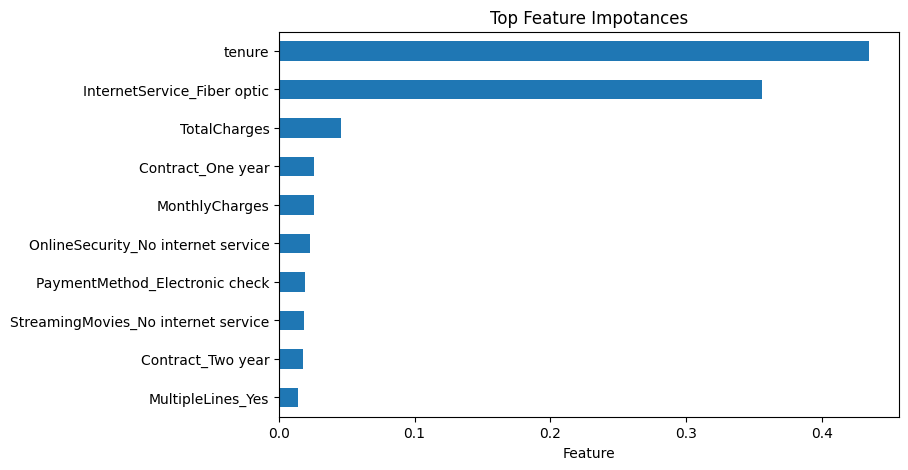

In [18]:
plt.figure(figsize=(8,5))
feature_importance.head(10).sort_values().plot(kind='barh')
plt.xlabel('Importance')
plt.xlabel('Feature')
plt.title('Top Feature Impotances')
plt.show()
#The feature importance results show that tenure is the most important feature 
#with an importance of 0.4353. The second most important feature is 
#InternetService_Fiber optic with an importance of 0.3564. Other important 
#features include TotalCharges, Contract_One year, and MonthlyCharges. 
#This shows that customer tenure and internet service type have a strong 
#influence on the model's churn predictions.

# Part 10 -Interpretation

# TASK-20
The feature importance results agree with the patterns found in Lab 2. Tenure was an important feature because customers with shorter tenure were more likely to churn, while longer-term customers were more likely to stay. InternetService was also related to churn, which supports the model's finding that Fiber optic service is an important feature.

# Part 11 — Conclusion 

# TASK-21
In this lab, I built a Decision Tree model to predict customer churn. The unrestricted tree had high training accuracy but showed clear overfitting, so I selected a maximum depth of 5. The entropy model performed slightly better overall, with an accuracy of 78.79% and an F1-score of 54.98%. The most important features were tenure and InternetService_Fiber optic. The main limitation is that the model still has a relatively low recall, meaning it misses some customers who actually churn.

# TASK-22
In the future, the model can be improved by using techniques such as Random Forest, Gradient Boosting, or Logistic Regression and comparing their results with the Decision Tree. Hyperparameter tuning can also be used to improve the model. Since recall for churn customers is relatively low, class balancing techniques can be applied to help the model identify more customers who are likely to churn.

# TASK-23

In [19]:
import pandas as pd
import math
data={
    'Outlook': ['Sunny','Sunny','Overcast','Rainy','Rainy','Rainy',
                'Overcast','Sunny','Sunny','Rainy','Sunny',
                'Overcast','Overcast','Rainy'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool',
                    'Cool', 'Mild', 'Cool', 'Mild', 'Mild',
                    'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal',
                 'Normal', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong',
             'Strong', 'Weak', 'Weak', 'Weak', 'Strong',
             'Strong', 'Weak', 'Strong'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No',
             'Yes', 'No', 'Yes', 'Yes', 'Yes',
             'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)
print(df)

     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3      Rainy        Mild     High    Weak  Yes
4      Rainy        Cool   Normal    Weak  Yes
5      Rainy        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9      Rainy        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13     Rainy        Mild     High  Strong   No


In [20]:
def entropy(target):
    values = target.value_counts()
    total = len(target)
    ent = 0
    for count in values:
        probability = count/total
        ent-= probability * math.log2(probability)
    return ent

In [21]:
def information_gain(df, attribute, target):
    total_entropy = entropy(df[target])

    values = df[attribute].unique()

    weighted_entropy = 0

    for value in values:
        subset = df[df[attribute] == value]
        weight = len(subset) / len(df)

        weighted_entropy += weight * entropy(subset[target])

    gain = total_entropy - weighted_entropy

    return gain

In [22]:
def id3(df, attributes, target, level=0):

    # If all target values are the same
    if len(df[target].unique()) == 1:
        return df[target].iloc[0]

    # If no attributes are left
    if len(attributes) == 0:
        return df[target].mode()[0]

    print("\n" + "  " * level + "Current split:")

    gains = {}

    for attribute in attributes:
        gain = information_gain(df, attribute, target)
        gains[attribute] = gain

        print("  " * level + f"Gain({attribute}) = {gain:.4f}")

    best_attribute = max(gains, key=gains.get)

    print("  " * level + f"Best attribute: {best_attribute}")

    tree = {best_attribute: {}}

    remaining_attributes = [
        attr for attr in attributes if attr != best_attribute
    ]

    for value in df[best_attribute].unique():

        subset = df[df[best_attribute] == value]

        tree[best_attribute][value] = id3(
            subset,
            remaining_attributes,
            target,
            level + 1
        )

    return tree

In [23]:
attributes = ['Outlook', 'Temperature', 'Humidity', 'Wind']

tree = id3(df, attributes, 'Play')

print("\nFinal ID3 Tree:")
print(tree)
#This code creates a small Play Badminton dataset and uses the ID3 algorithm to build a decision tree. 
#It calculates entropy and information gain for each attribute, selects the best attribute at each step, and finally prints the complete decision tree.


Current split:
Gain(Outlook) = 0.2467
Gain(Temperature) = 0.0292
Gain(Humidity) = 0.1518
Gain(Wind) = 0.0481
Best attribute: Outlook

  Current split:
  Gain(Temperature) = 0.5710
  Gain(Humidity) = 0.9710
  Gain(Wind) = 0.0200
  Best attribute: Humidity

  Current split:
  Gain(Temperature) = 0.0200
  Gain(Humidity) = 0.0200
  Gain(Wind) = 0.9710
  Best attribute: Wind

Final ID3 Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rainy': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}


## Submission Checklist
Student-info block (Name, ID, Section, GitHub, Kaggle, Dataset, Dataset Source) 
1. Problem Definition [x]
2. Dataset Verification [x]
3. Feature & Target Preparation [x]
4. Train/Test Split [x]
5. Baseline Decision Tree [x]
6. Model Evaluation [x]
7. Overfitting Experiment [x]
8. Model Comparison [x]
9. Feature Importance [x]
10. Interpretation [x]
11. Conclusion [x]